# Workload Forecasting: Practical Student Benchmark

This notebook compares LSTM, HBNN, and LSTMD for CPU and memory workload forecasting using the paper's 288-step history and 2-step horizon. It uses one representative processed trace, 200 maximum epochs per model, early stopping, and bounded windows so the experiment can finish on Kaggle while remaining meaningful for a student project.

The run produces raw metrics, aggregate tables, predictions, uncertainty estimates, runtime measurements, checkpoints, and plots under `results/`.

In [ ]:
import os
import subprocess

repo_path = "/kaggle/working/ML_Proj"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/grass-overflow/ML_Proj.git", repo_path],
        check=True,
    )
os.chdir(repo_path)
print(f"Working directory: {os.getcwd()}")

Cloning into 'ML_Proj'...
remote: Enumerating objects: 1026, done.
remote: Counting objects: 100% (1026/1026), done.
remote: Compressing objects: 100% (625/625), done.
remote: Total 1026 (delta 371), reused 1026 (delta 371), pack-reused 0 (from 0)
Receiving objects: 100% (1026/1026), 2.95 MiB | 2.62 MiB/s, done.
Resolving deltas: 100% (371/371), done.
/content/ML_Proj/ML_Proj/ML_Proj


### Install Kaggle-Compatible Dependencies

Kaggle preinstalls JAX, but the pinned TensorFlow 2.16 environment requires an older `ml_dtypes` version. Remove the unrelated JAX packages first so TensorFlow can import cleanly in the experiment subprocess.

In [ ]:
%pip uninstall -y jax jaxlib
%pip install -q -r requirements-cpu.txt

  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done


### Run Quick Kaggle Smoke Test

This runs LSTM, HBNN, and LSTMD once on the bounded `gc19_a` bivariate task. It is intentionally the short working test: three epochs maximum, bounded windows, and saved metrics, predictions, runtime data, and plots.

In [ ]:
!python run_experiments.py --mode quick --runs 1

2026-10-01 13:53:28.733487: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
Epoch 1/3
New best validation loss:  0.4494396150112152
7/7 - 4s - loss: 0.4769 - mse: 0.4769 - mae: 0.6725 - val_loss: 0.4494 - val_mse: 0.4494 - val_mae: 0.6574 - 4s/epoch - 548ms/step
Epoch 2/3
New best validation loss:  0.4248059391975403
7/7 - 1s - loss: 0.4397 - mse: 0.4397 - mae: 0.6447 - val_loss: 0.4248 - val_mse: 0.4248 - val_mae: 0.6386 - 1s/epoch - 182ms/step
Epoch 3/3
New best validation loss:  0.40344300866127014
7/7 - 1s - loss: 0.4170 - mse: 0.4170 - mae: 0.6273 - val_loss: 0.4034 - val_mse: 0.4034 - val_mae: 0.6220 - 1s/epoch - 174ms/step
Restoring model weights from the end of the best epoch: 3.
Model save id  0000
S-B-LSTM gc19_a seed 17: MSE 0.387755, MAE 0.599031
Epoch 1/3
New best validation loss:  122.4095458984375
7/7 - 5s - loss: 2.7003 - mse: 1.8659 - mae: 1.0512 - val_loss: 122.4

### Inspect Results

The table below summarizes the repeated test results. The CSV files remain the authoritative artifacts for the report, and the plots provide forecast, uncertainty, calibration, and runtime figures.

results/plots/dataset_wise_performance.png


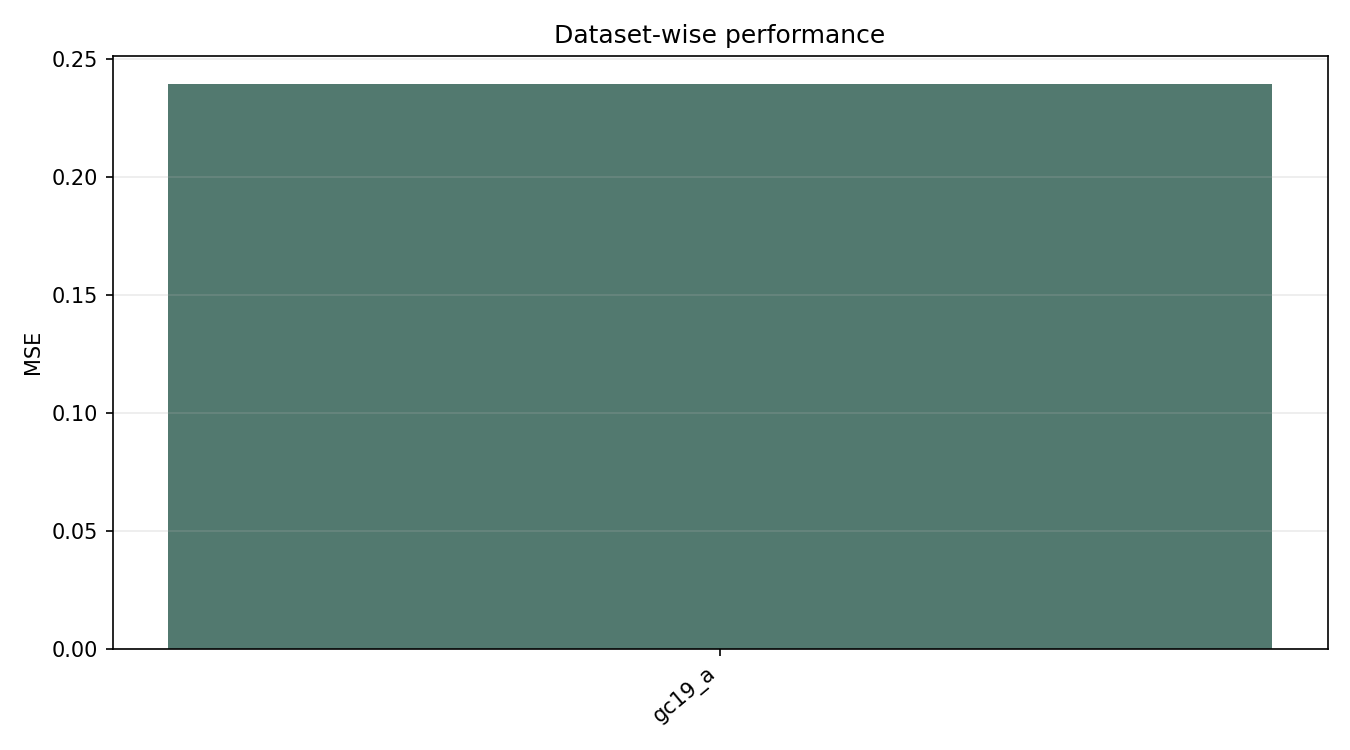

results/plots/epistemic_vs_aleatoric_uncertainty.png


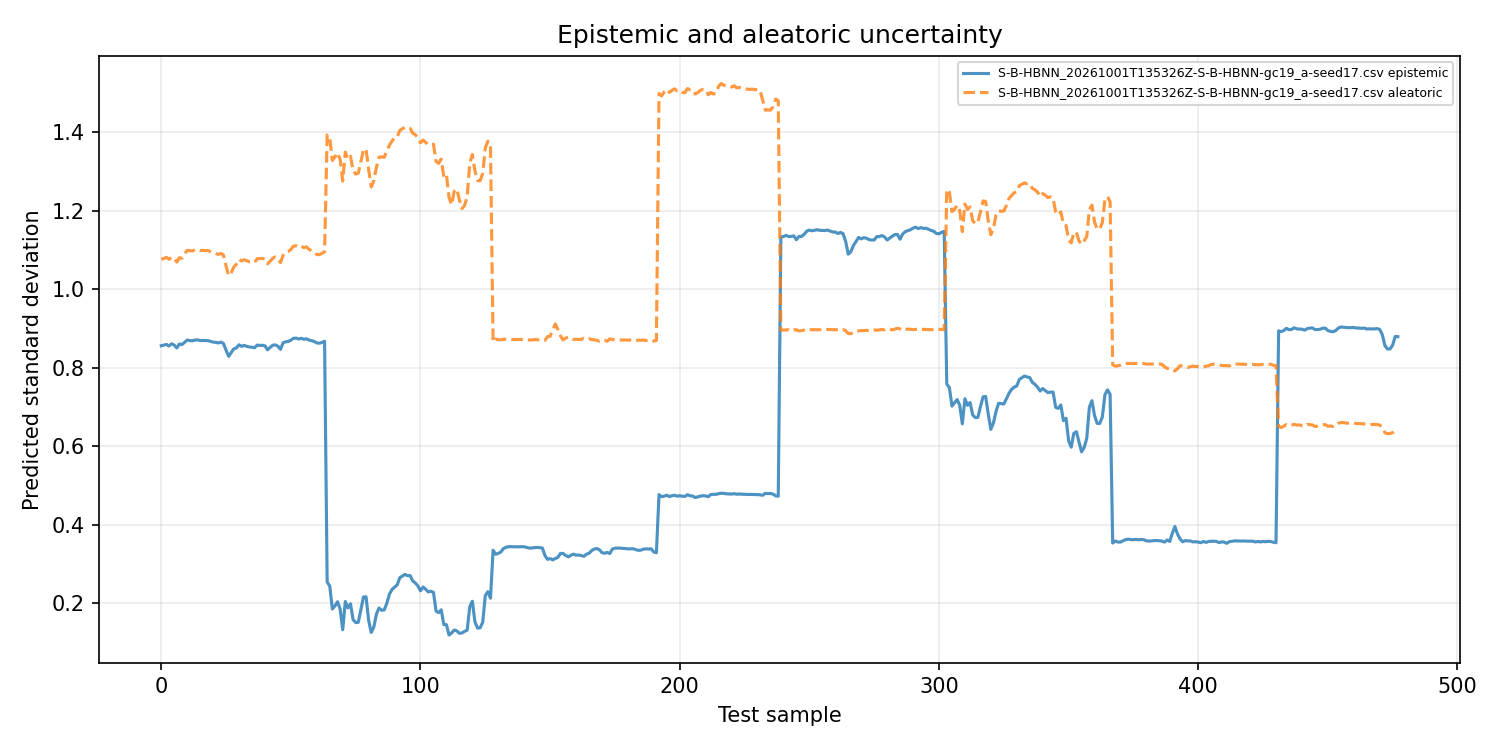

results/plots/fine_tuning_time_comparison.png


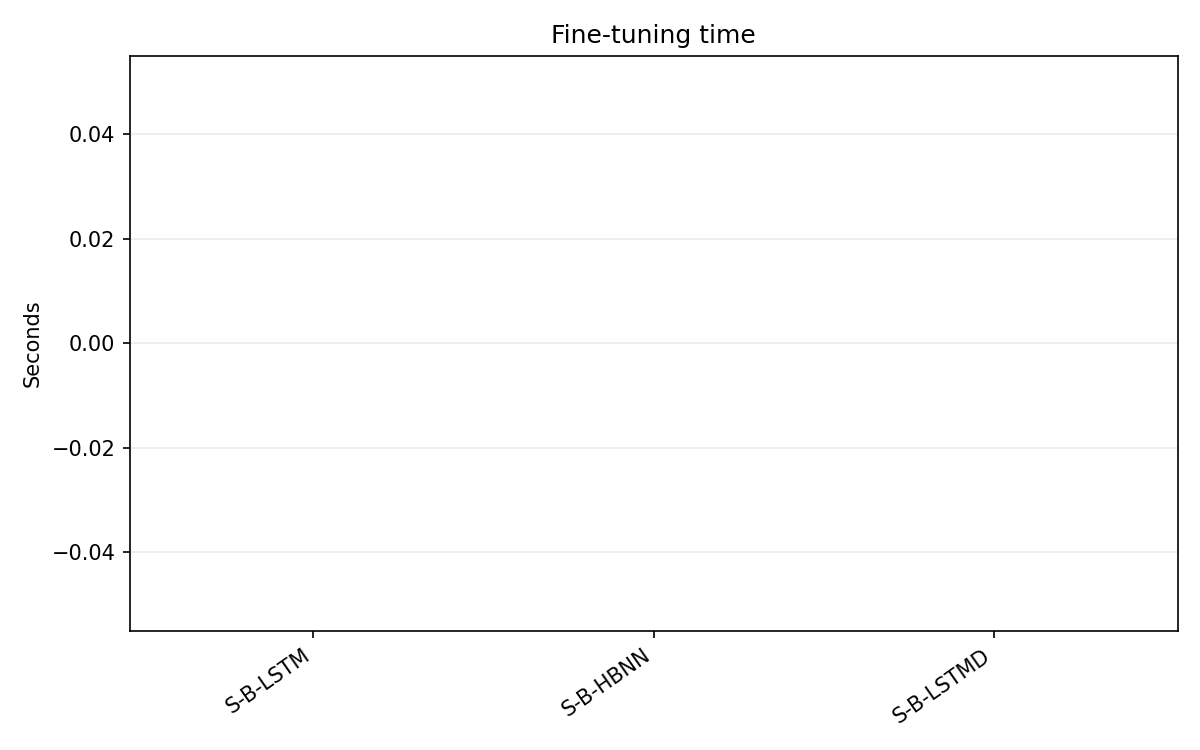

results/plots/inference_time_comparison.png


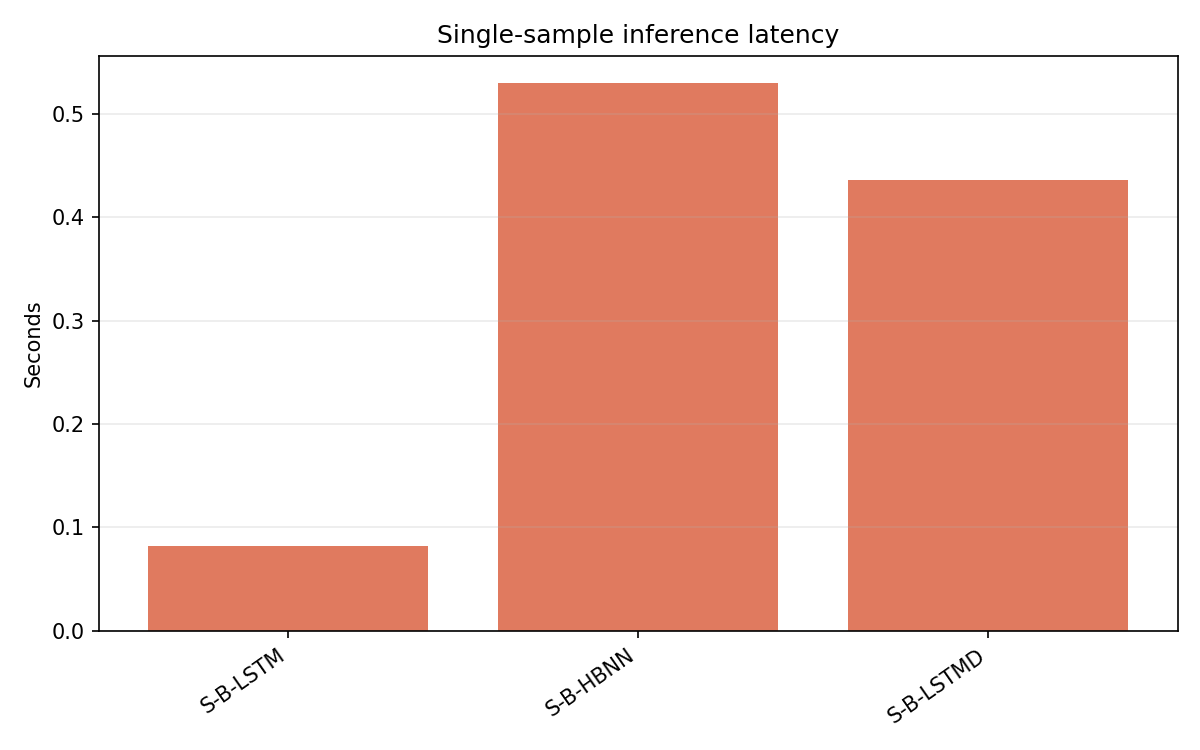

results/plots/mae_comparison.png


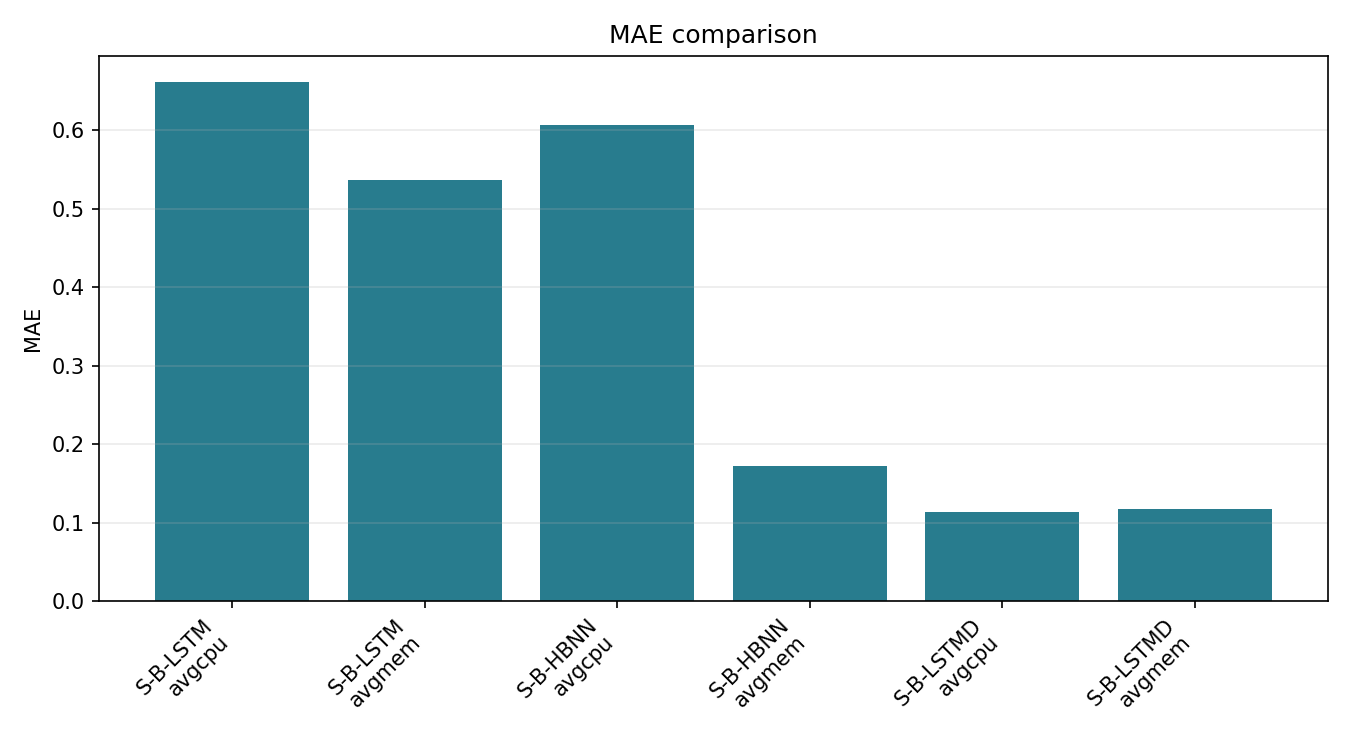

results/plots/mse_comparison.png


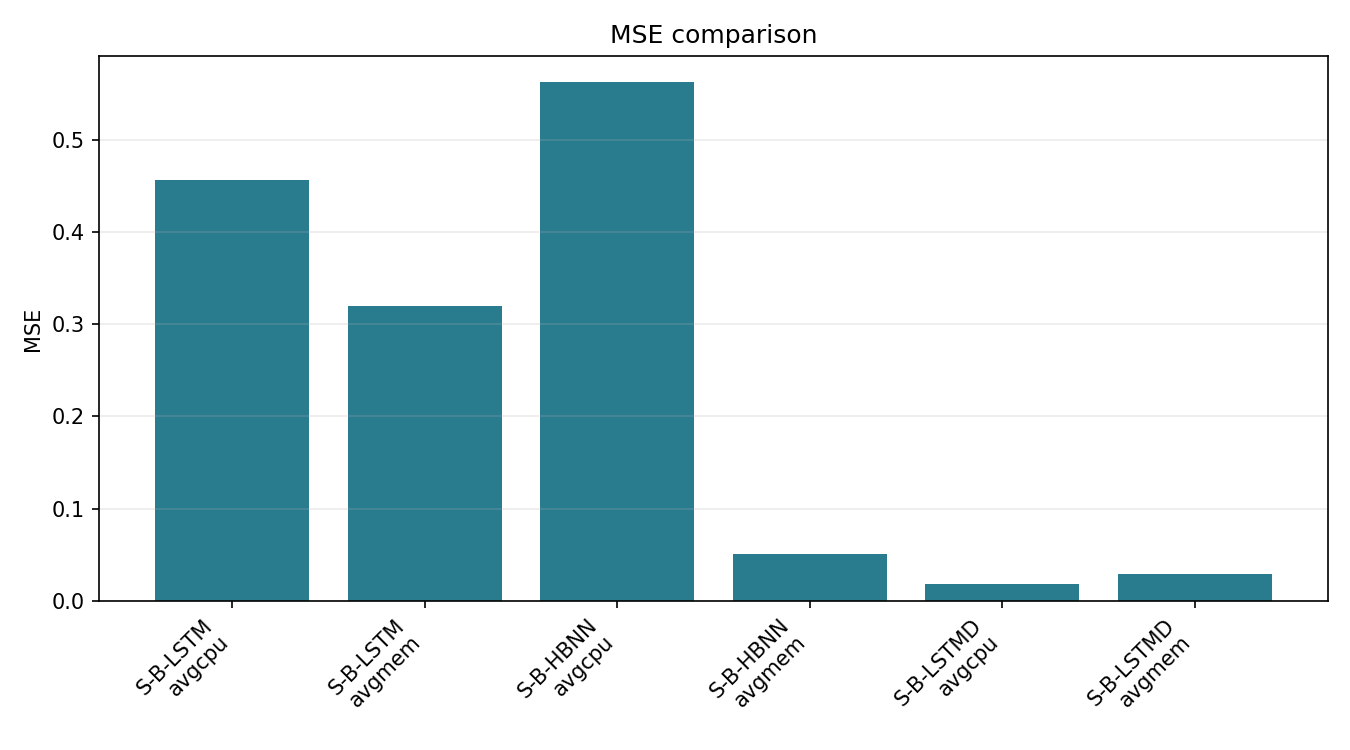

results/plots/prediction_S-B-HBNN_20261001T135326Z-S-B-HBNN-gc19_a-seed17.png


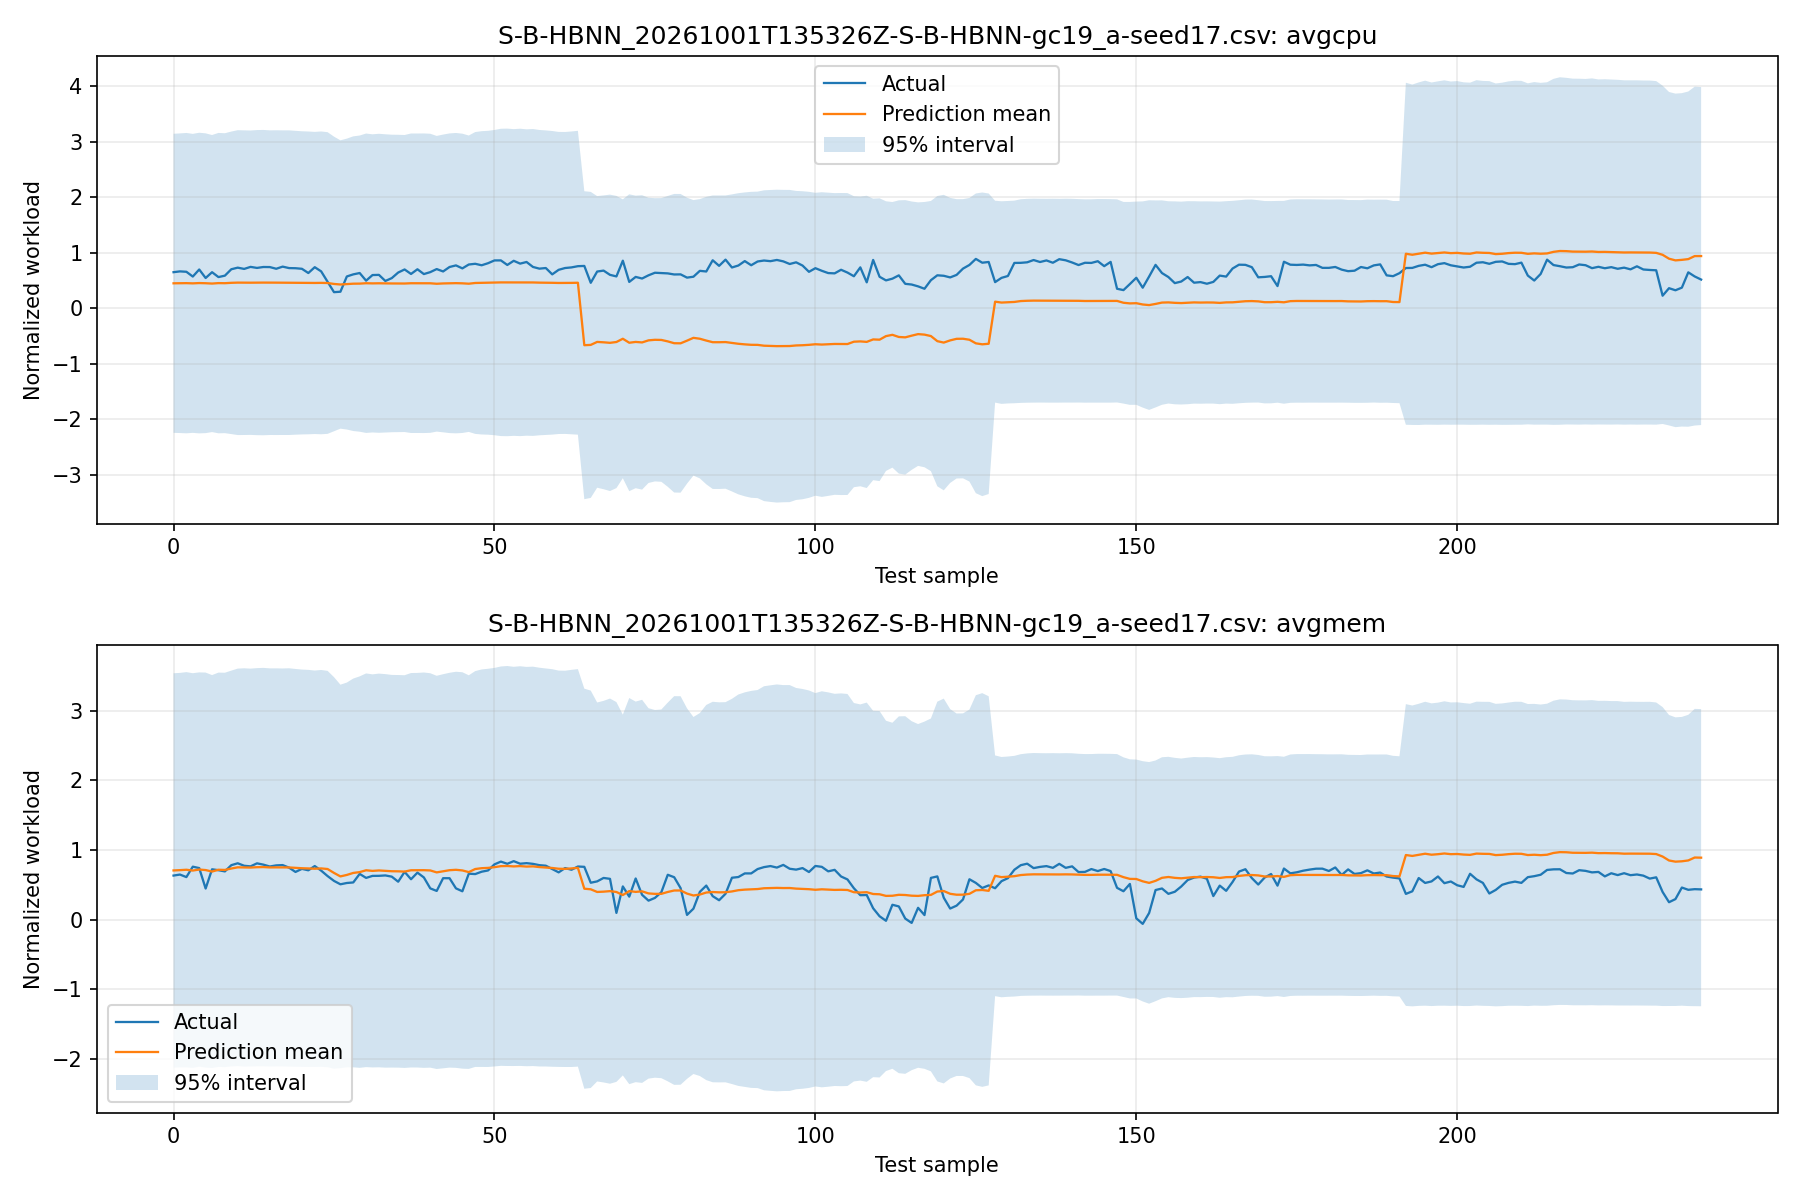

results/plots/prediction_S-B-LSTMD_20261001T135326Z-S-B-LSTMD-gc19_a-seed17.png


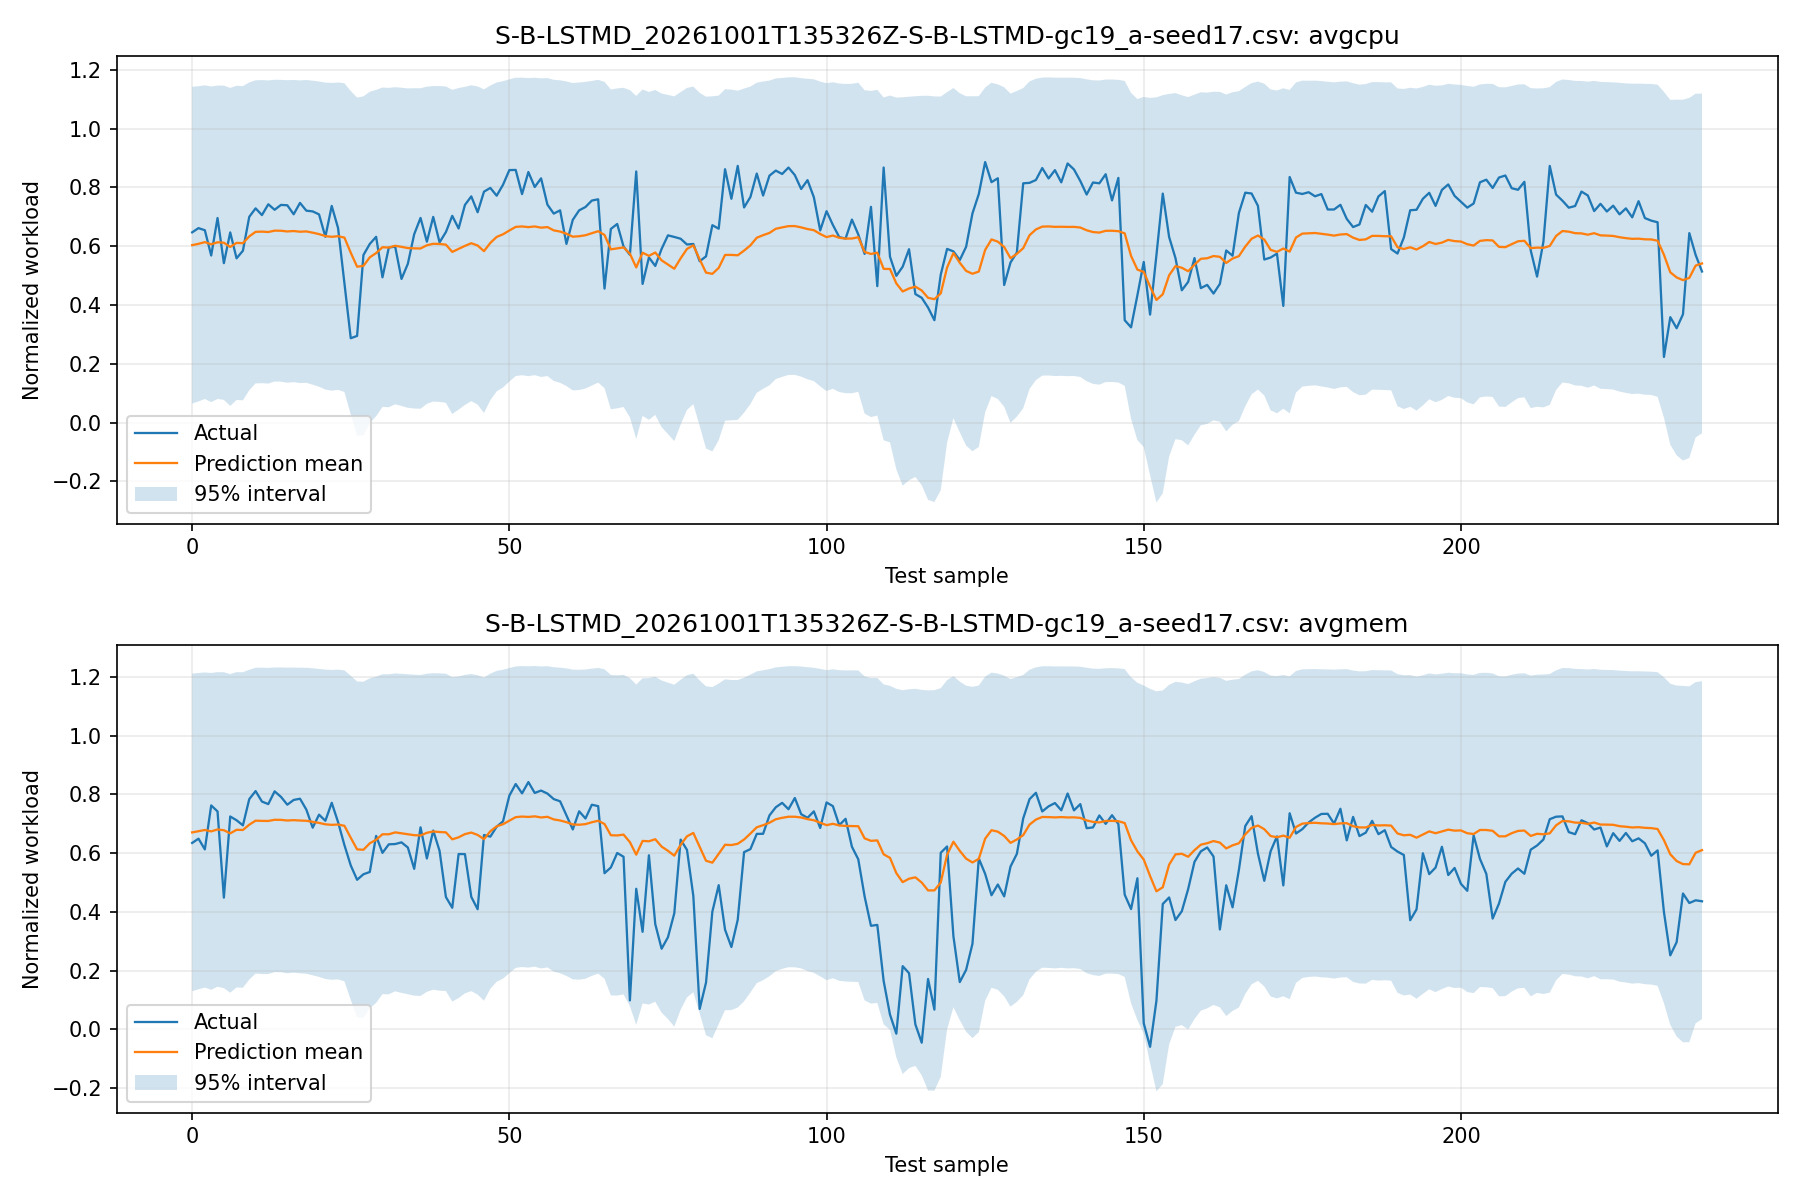

results/plots/prediction_S-B-LSTM_20261001T135326Z-S-B-LSTM-gc19_a-seed17.png


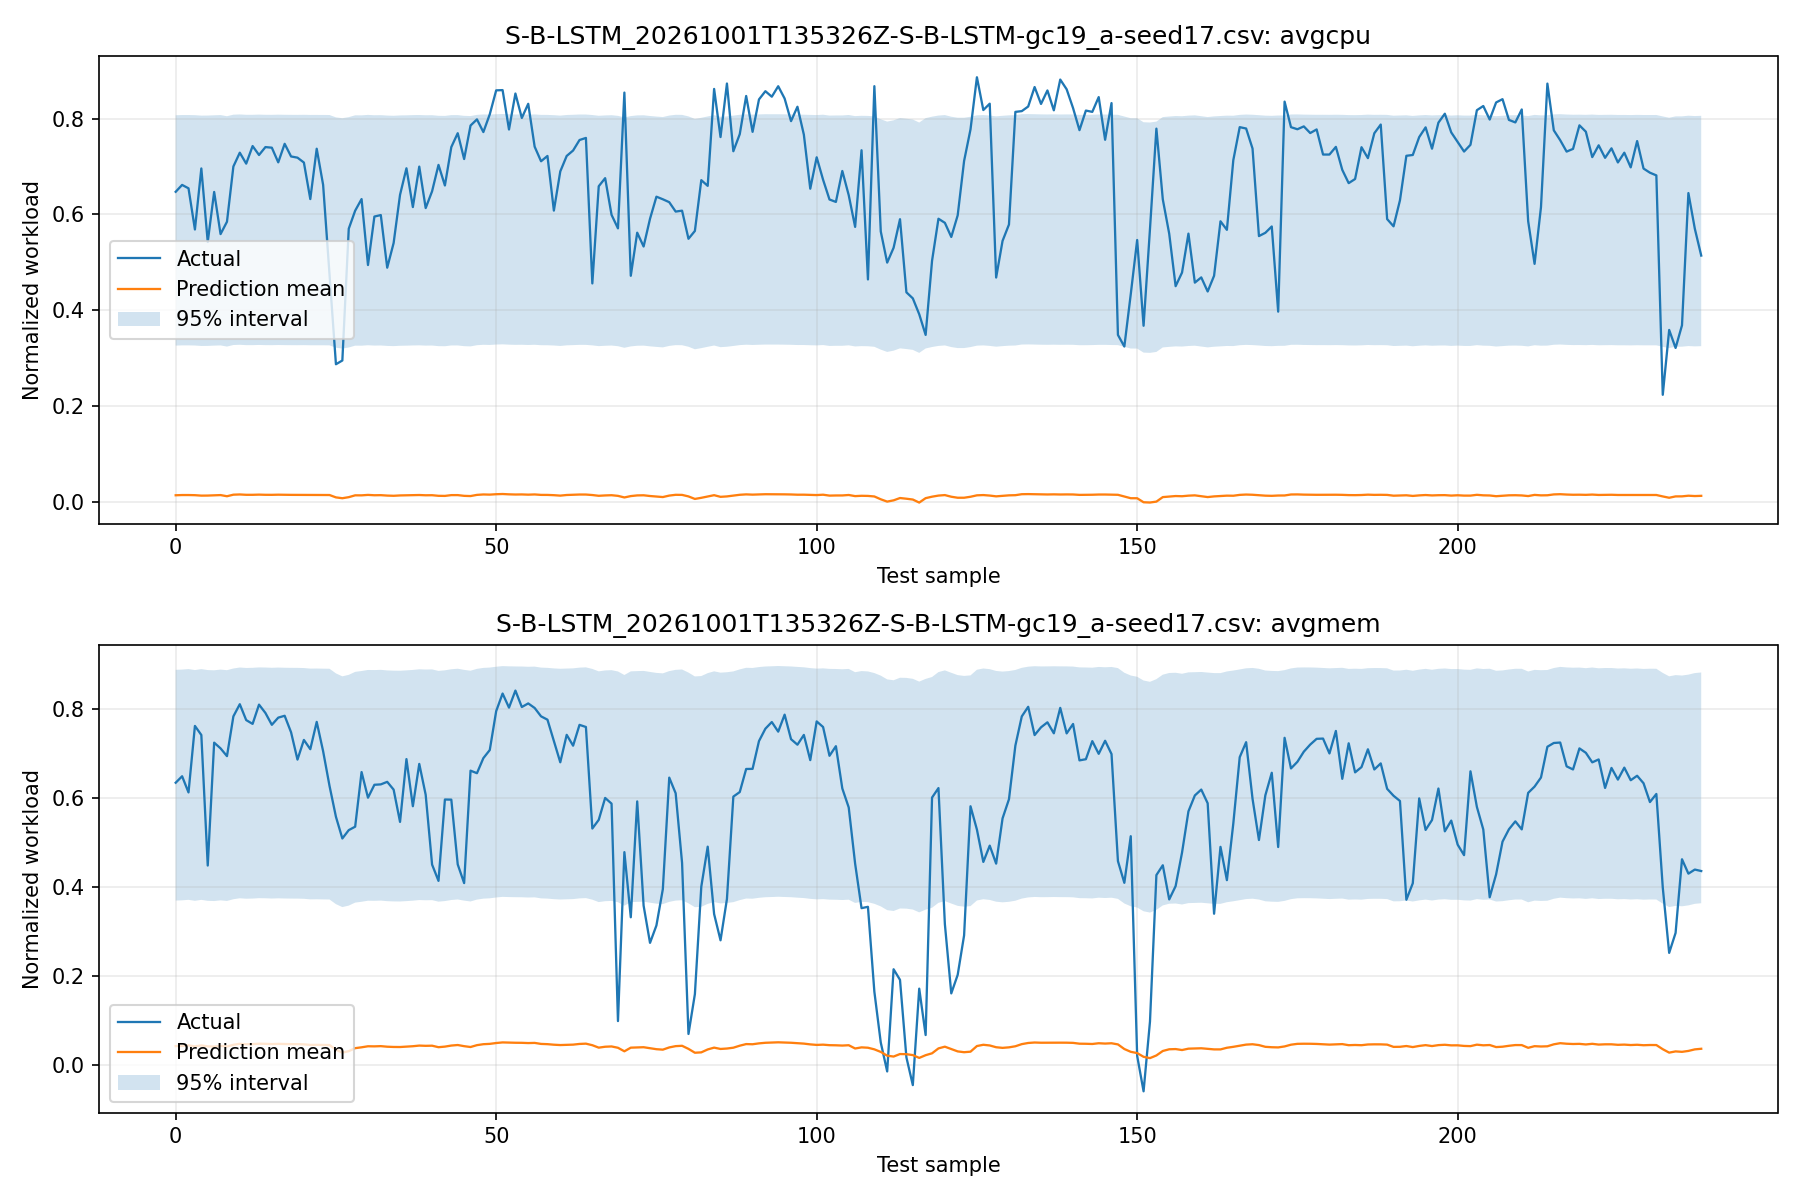

results/plots/quantile_loss_comparison.png


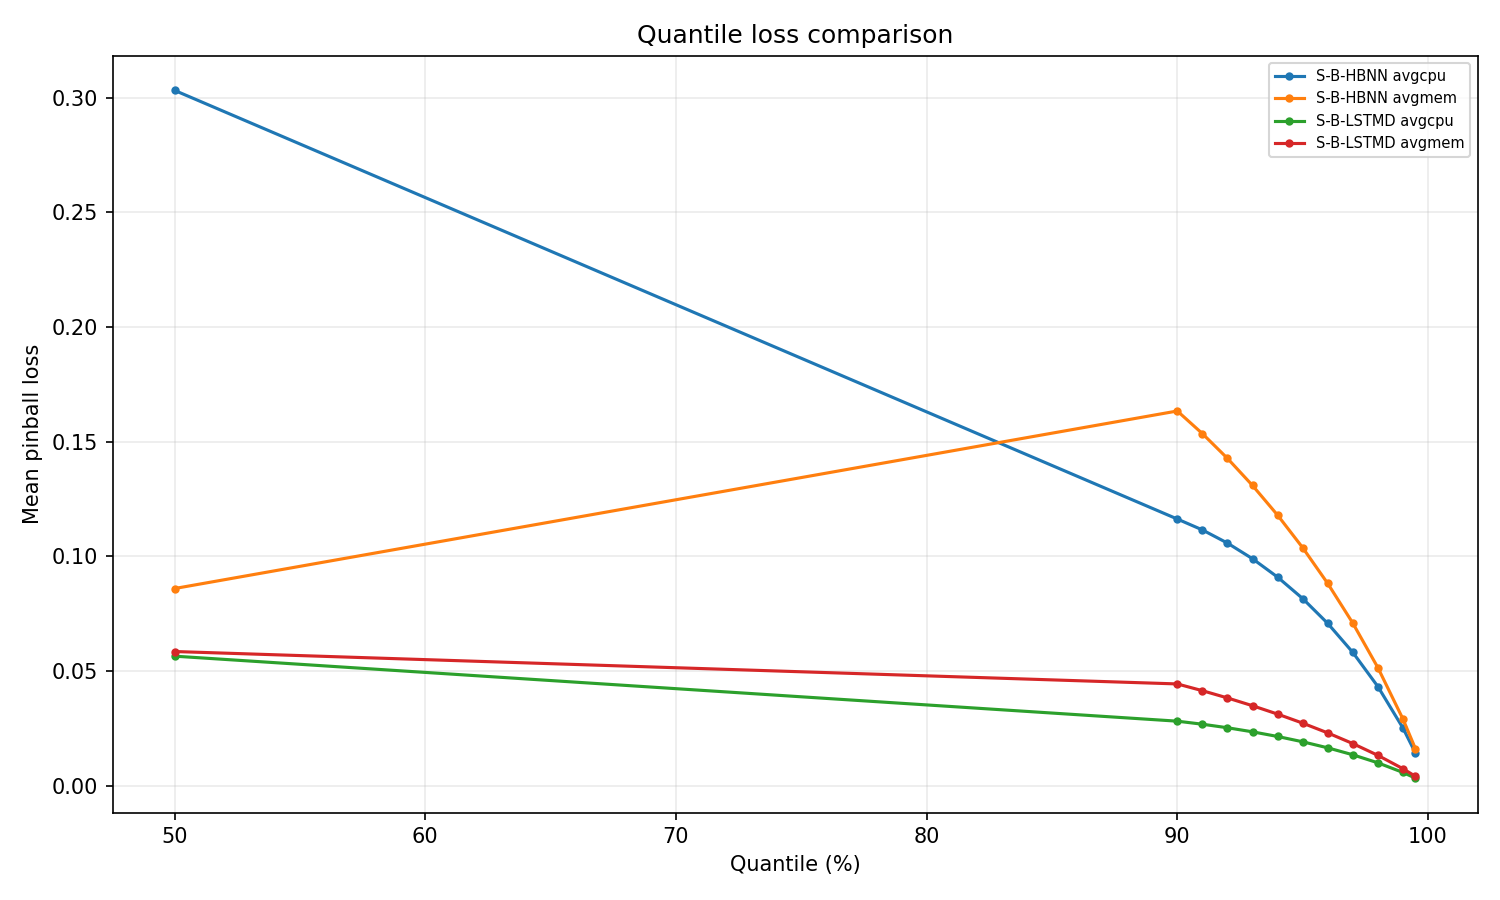

results/plots/rmse_comparison.png


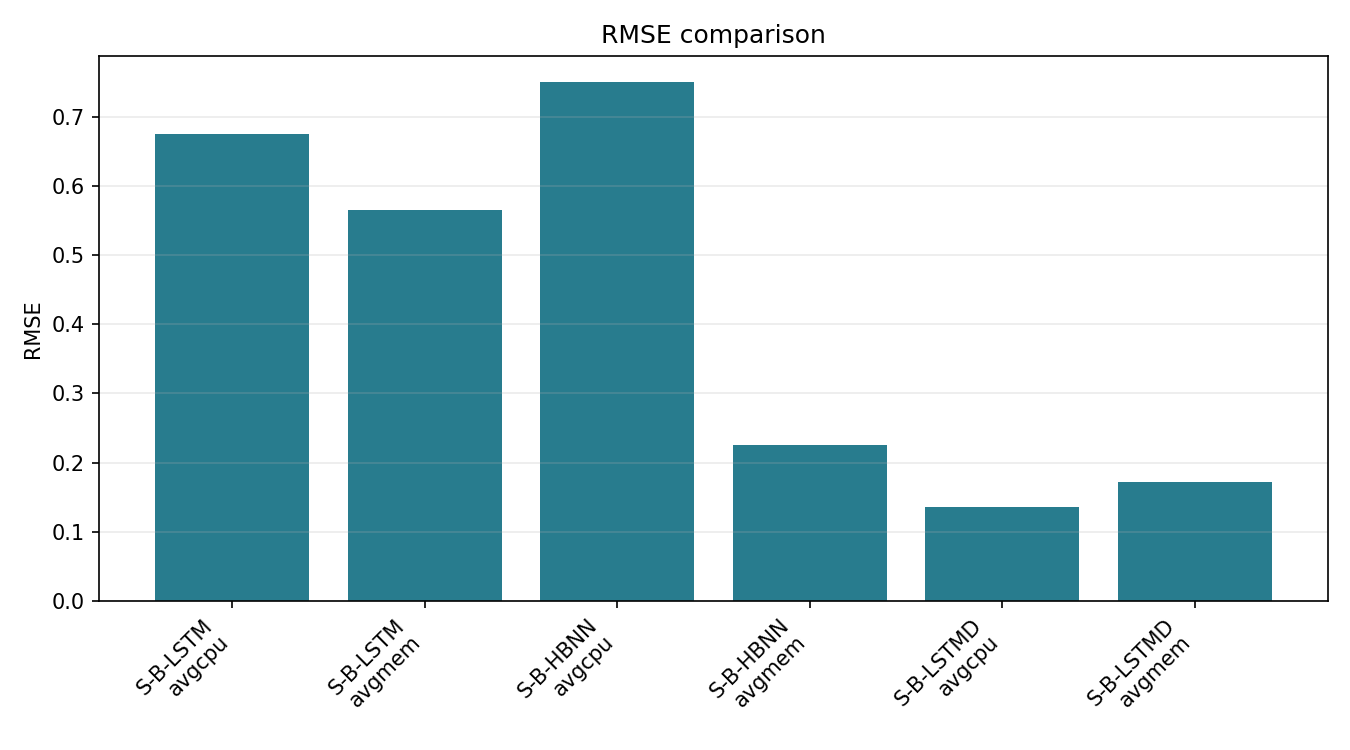

results/plots/service_level_vs_success_rate.png


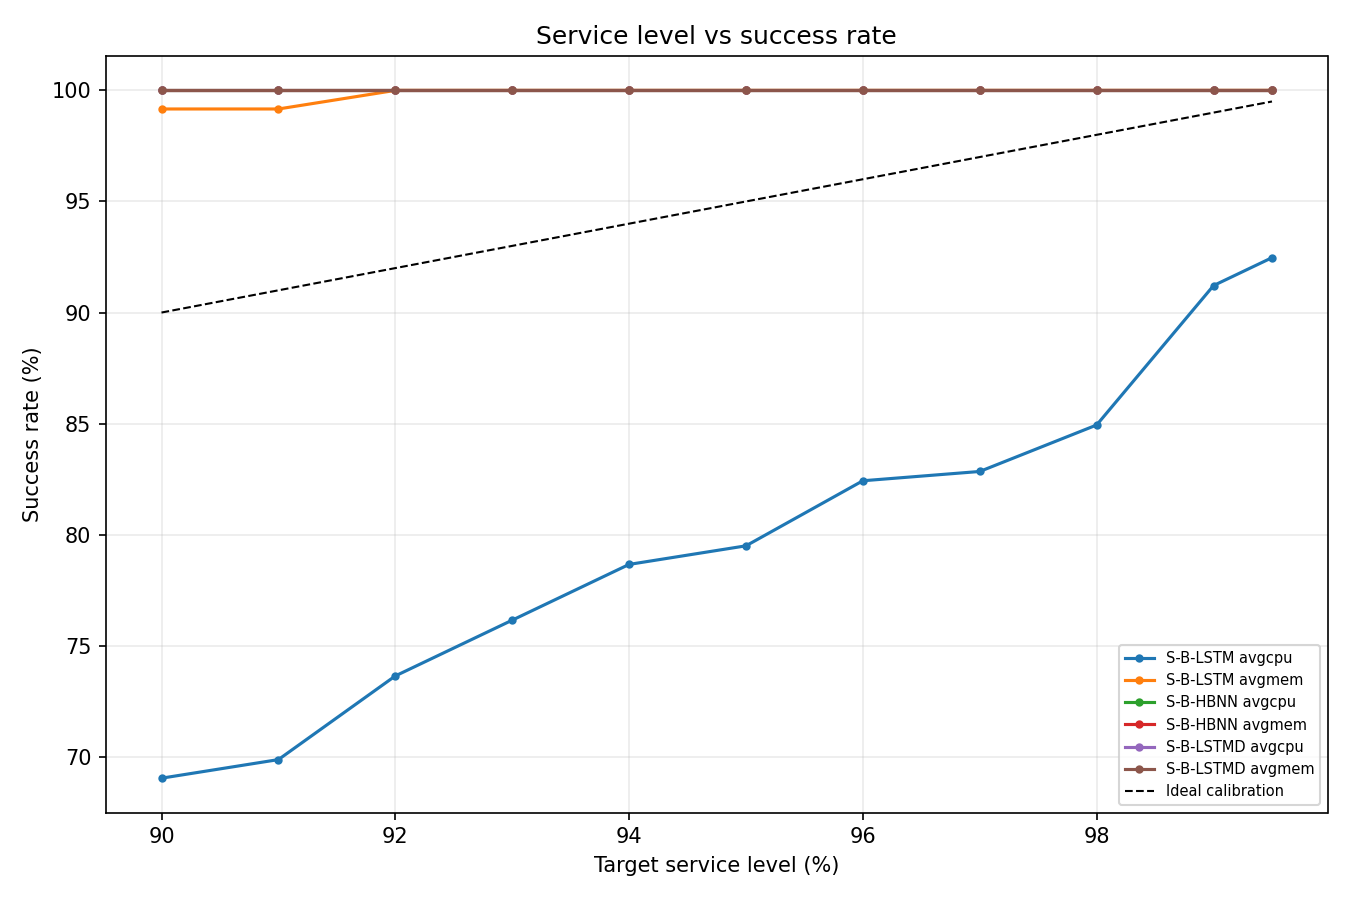

results/plots/service_level_vs_tpr.png


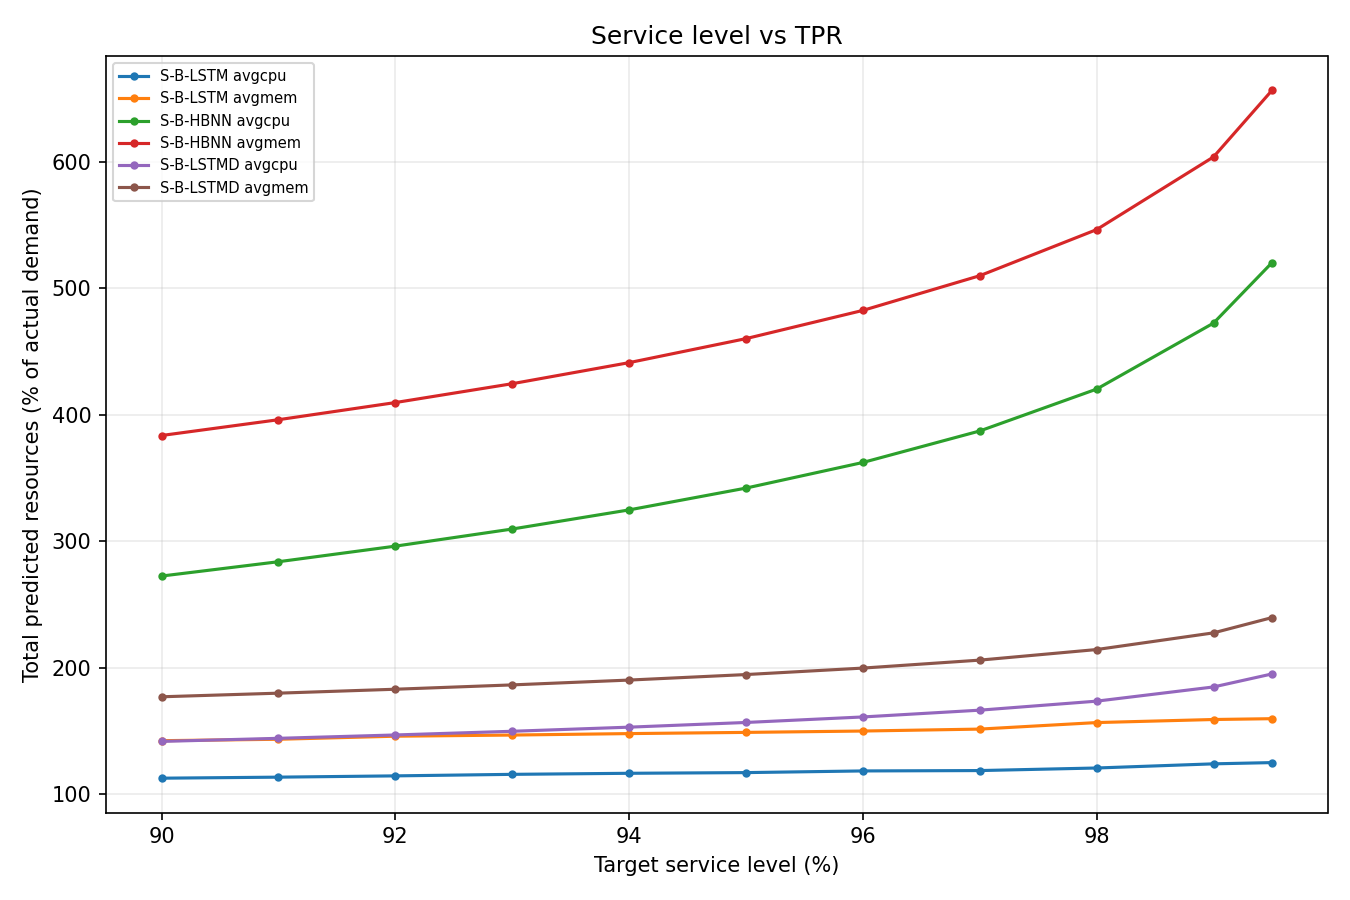

results/plots/tpr_vs_sr.png


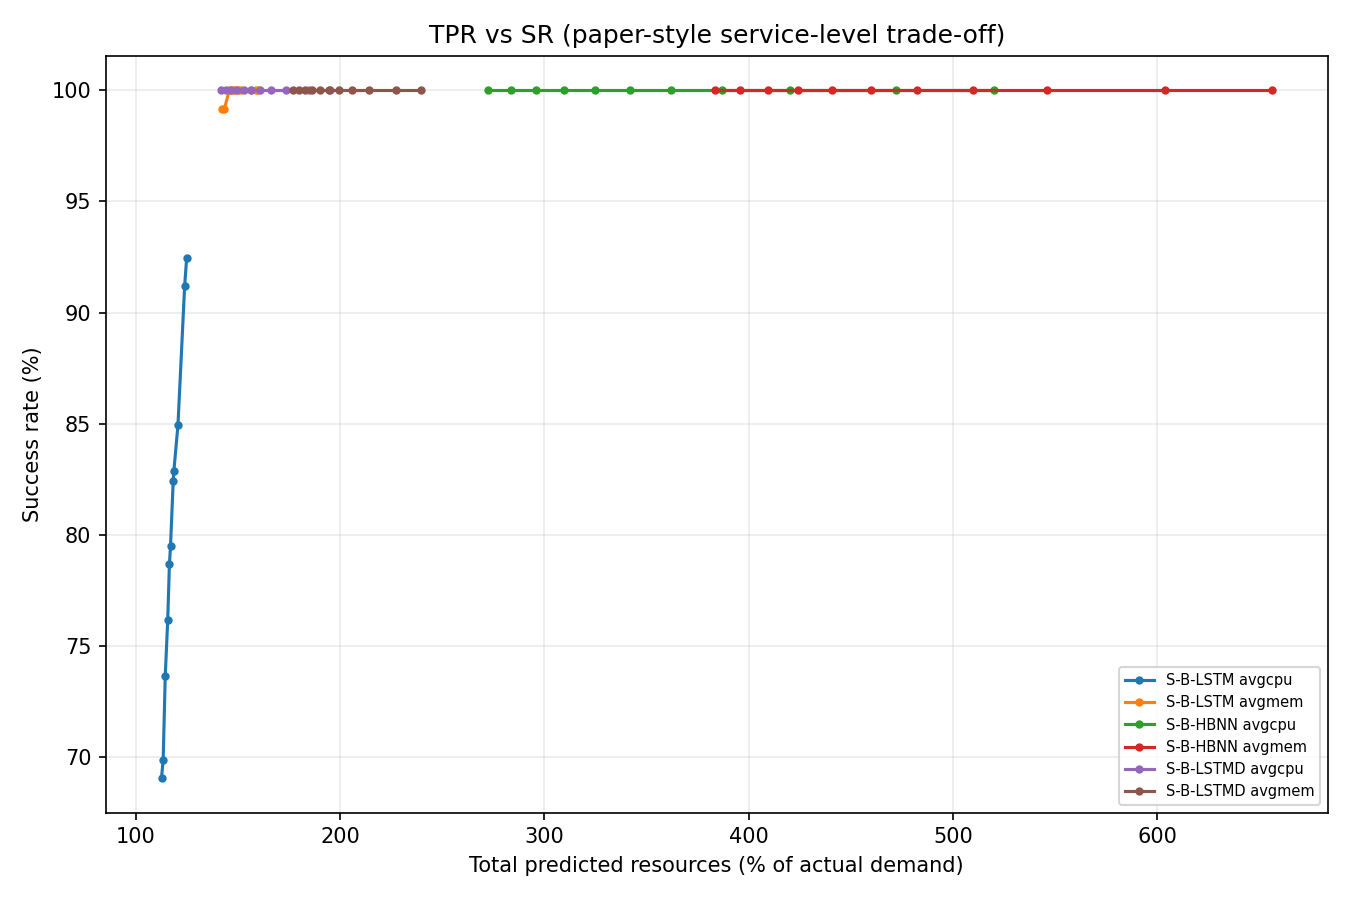

results/plots/training_time_comparison.png


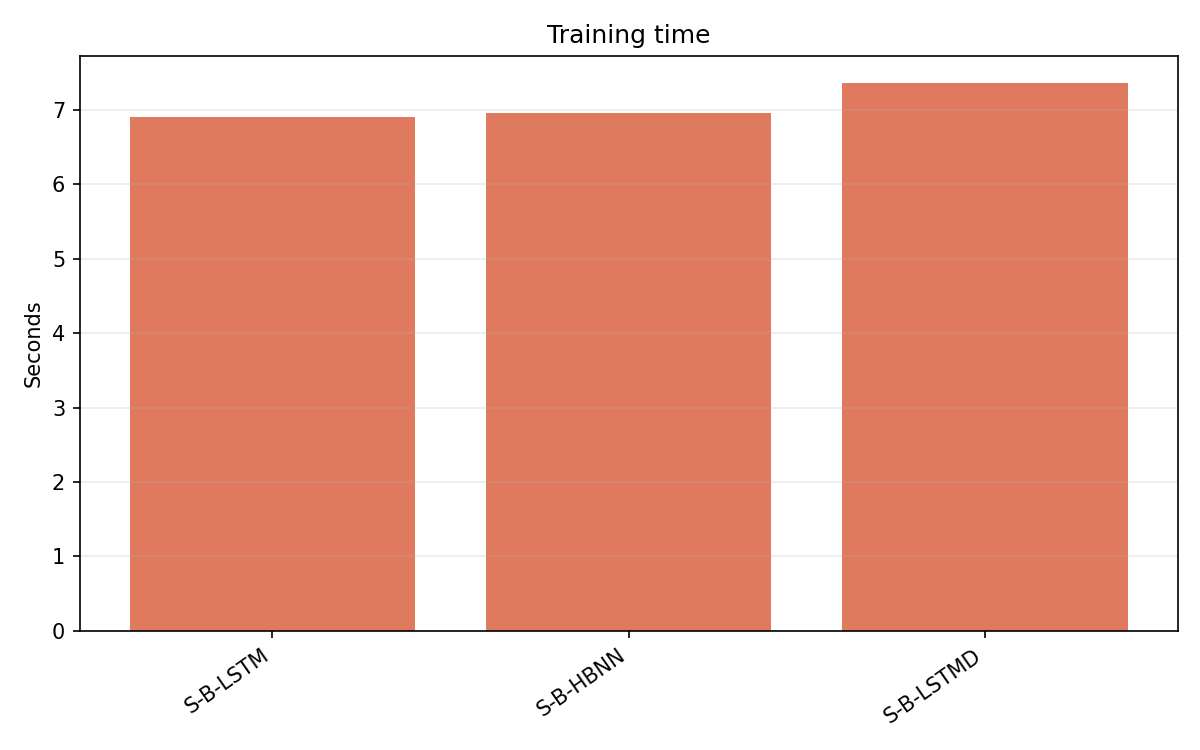

In [ ]:
import pandas as pd
from glob import glob
from IPython.display import Image, display

metrics_path = "results/aggregated/model_metrics.csv"
if os.path.exists(metrics_path):
    metrics = pd.read_csv(metrics_path)
    columns = [
        "model", "dataset", "resource", "run_count",
        "MSE_mean", "MSE_std", "MAE_mean", "MAE_std", "RMSE_mean",
    ]
    display(metrics[[column for column in columns if column in metrics]])
else:
    print("Run the benchmark cell first; no aggregated metrics were found.")

plot_files = sorted(glob("results/plots/*.png"))
print(f"Generated plots: {len(plot_files)}")
for path in plot_files:
    print(path)
    display(Image(filename=path))